# Notebook 18 — Gold & FX Signal Discovery

> *Does the EEM-lag approach extend to Gold and USD/THB? What cross-asset signals exist?*

**Motivation:** NB12 showed Gold DirAcc = 65.2% (best of 3 targets) and NLP added +0.20 Sharpe.  
Thai Gold market has high retail participation and tight USD/THB linkage — potentially more predictable than equities.

| Section | Content |
|---|---|
| 1. Signal Grid | IC map: all key signals vs all targets |
| 2. Gold Strategy | Best signal(s) for gold_ret_w |
| 3. FX Strategy | Best signal(s) for USD/THB |
| 4. Multi-Asset Portfolio | Combine SET + Gold + FX strategies |
| 5. Verdict | Which assets are most predictable? |

---
## Section 1 — Setup & Signal Grid

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})

df = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True).sort_index()

TC = 0.001

# ── Targets ──
TARGETS = {
    'SET':   'SET_index_ret_w_fwd1',
    'Gold':  'gold_ret_w_fwd1',
    'USDTHB':'USD_THB_ret_w_fwd1',
}
for k, col in TARGETS.items():
    if col not in df.columns:
        src = col.replace('_fwd1', '')
        if src in df.columns:
            df[col] = df[src].shift(-1)

# ── Candidate signals (lag-1, no lookahead) ──
SIGNALS = [
    'eem_ret_d_lag1',
    'sp500_ret_w',
    'sp500_ret_d_lag1',
    'gold_ret_w',           # gold predicts gold next week? (momentum)
    'gold_ret_d_lag1',
    'dxy_ret_w',
    'dxy_ret_d_lag1',
    'oil_ret_w',
    'oil_ret_d_lag1',
    'us_10yr_treasury_ret_w',
    'vix_z',
    'SET_index_ret_w',      # SET momentum
    'SET_index_rvol_4w',
    'gold_rvol_4w',
    'yield_curve_slope',
]
SIGNALS = [s for s in SIGNALS if s in df.columns]
print(f'Signals: {len(SIGNALS)}, Targets: {len(TARGETS)}')
print(f'Data: {len(df)} weeks ({df.index[0].date()} -> {df.index[-1].date()})')

Signals: 14, Targets: 3
Data: 1322 weeks (2000-09-01 -> 2025-12-26)


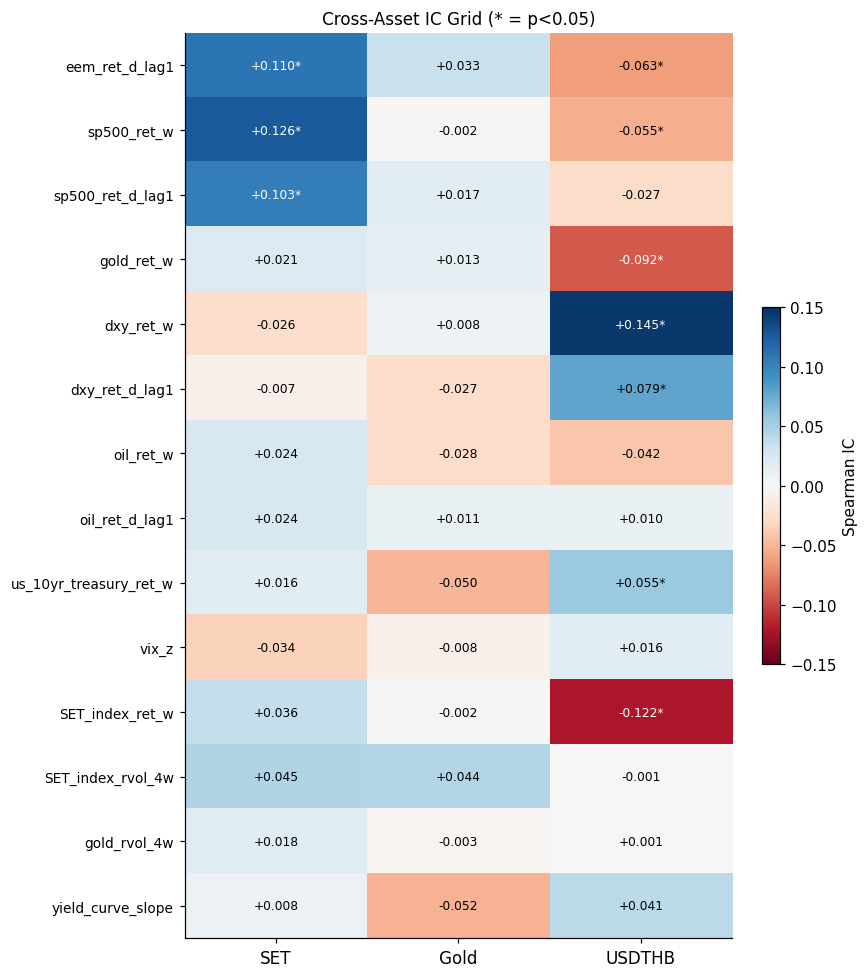


Top signals per target:
  SET: sp500_ret_w=+0.126(p=0.000), eem_ret_d_lag1=+0.110(p=0.000), sp500_ret_d_lag1=+0.103(p=0.000)
  Gold: yield_curve_slope=-0.052(p=0.059), us_10yr_treasury_ret_w=-0.050(p=0.071), SET_index_rvol_4w=+0.044(p=0.111)
  USDTHB: dxy_ret_w=+0.145(p=0.000), SET_index_ret_w=-0.122(p=0.000), gold_ret_w=-0.092(p=0.001)


In [2]:
# ── IC grid: all signals vs all targets ──
ic_grid = pd.DataFrame(index=SIGNALS, columns=list(TARGETS.keys()), dtype=float)
p_grid  = pd.DataFrame(index=SIGNALS, columns=list(TARGETS.keys()), dtype=float)

for sig in SIGNALS:
    for tgt_name, tgt_col in TARGETS.items():
        sub = df[[sig, tgt_col]].dropna()
        if len(sub) < 50:
            continue
        ic, p = spearmanr(sub[sig], sub[tgt_col])
        ic_grid.loc[sig, tgt_name] = ic
        p_grid.loc[sig,  tgt_name] = p

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 9))
ic_vals = ic_grid.astype(float).values
im = ax.imshow(ic_vals, cmap='RdBu', vmin=-0.15, vmax=0.15, aspect='auto')
ax.set_xticks(range(len(TARGETS))); ax.set_xticklabels(list(TARGETS.keys()), fontsize=11)
ax.set_yticks(range(len(SIGNALS))); ax.set_yticklabels(SIGNALS, fontsize=9)
for i, sig in enumerate(SIGNALS):
    for j, tgt in enumerate(TARGETS.keys()):
        ic_v = ic_grid.loc[sig, tgt]
        p_v  = p_grid.loc[sig, tgt]
        if pd.isna(ic_v): continue
        star = '*' if p_v < 0.05 else ''
        ax.text(j, i, f'{ic_v:+.3f}{star}', ha='center', va='center', fontsize=8,
                color='white' if abs(ic_v) > 0.08 else 'black')
plt.colorbar(im, ax=ax, fraction=0.03, label='Spearman IC')
ax.set_title('Cross-Asset IC Grid (* = p<0.05)', fontsize=11)
plt.tight_layout()
plt.savefig(FIGS / 'cross_asset_ic_grid.png', bbox_inches='tight')
plt.show()

print('\nTop signals per target:')
for tgt in TARGETS:
    top = ic_grid[tgt].abs().nlargest(3)
    print(f'  {tgt}: ' + ', '.join(f'{s}={ic_grid.loc[s,tgt]:+.3f}(p={p_grid.loc[s,tgt]:.3f})' for s in top.index))

---
## Section 2 — Gold Signal Strategy

In [3]:
TARGET_GOLD = TARGETS['Gold']

def risk_metrics(rets, freq=52):
    r = pd.Series(rets).dropna()
    if len(r) < 10: return {}
    ann_ret = (1+r).prod()**(freq/len(r)) - 1
    ann_vol = r.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1+r).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'ann_ret':ann_ret,'ann_vol':ann_vol,'sharpe':sharpe,
            'max_dd':max_dd,'win_rate':(r>0).mean(),'n':len(r)}

def backtest_rule(signal, target, variant='lf', tc=TC):
    sub = pd.concat([signal, target], axis=1).dropna()
    sub.columns = ['sig', 'tgt']
    pos = np.sign(sub['sig'])
    if variant == 'lf': pos = pos.clip(lower=0)
    pos_change = pos.diff().abs().fillna(pos.abs())
    gross = pos * sub['tgt']
    net   = gross - pos_change * tc
    return gross, net

# Find best signal for Gold
gold_sigs = ic_grid['Gold'].dropna().abs().sort_values(ascending=False)
print('Gold signal ranking (by |IC|):')
print(f'{"Signal":<30} {"IC":>8} {"p":>8} {"Sharpe L/flat":>14}')
print('-' * 65)
for sig in gold_sigs.head(8).index:
    ic_v = ic_grid.loc[sig, 'Gold']
    p_v  = p_grid.loc[sig, 'Gold']
    # sign-flip if IC is negative (short when signal up)
    sig_ser = df[sig] * np.sign(ic_v)
    _, net = backtest_rule(sig_ser, df[TARGET_GOLD], 'lf')
    m = risk_metrics(net)
    sig_flag = ' *' if p_v < 0.05 else ''
    print(f'{sig:<30} {ic_v:>+8.4f} {p_v:>8.4f}{sig_flag} {m.get("sharpe",np.nan):>14.3f}')

Gold signal ranking (by |IC|):
Signal                               IC        p  Sharpe L/flat
-----------------------------------------------------------------
yield_curve_slope               -0.0519   0.0594          0.480
us_10yr_treasury_ret_w          -0.0497   0.0707          0.422
SET_index_rvol_4w               +0.0438   0.1114          0.726
eem_ret_d_lag1                  +0.0333   0.2529          0.589
oil_ret_w                       -0.0276   0.3170          0.402
dxy_ret_d_lag1                  -0.0272   0.3237          0.380
sp500_ret_d_lag1                +0.0170   0.5372          0.547
gold_ret_w                      +0.0133   0.6304          0.417


In [4]:
# Best Gold strategy: top-2 signals combined
best_gold_sigs = ic_grid['Gold'].dropna().abs().nlargest(2).index.tolist()
print(f'Best Gold signals: {best_gold_sigs}')

# Composite signal: average of normalised best signals
gold_composite = pd.Series(0.0, index=df.index)
for sig in best_gold_sigs:
    ic_v   = ic_grid.loc[sig, 'Gold']
    s_norm = df[sig] / df[sig].rolling(52, min_periods=26).std()
    gold_composite += np.sign(ic_v) * s_norm
gold_composite = gold_composite / len(best_gold_sigs)

# Backtest
gross_gold, net_gold = backtest_rule(gold_composite, df[TARGET_GOLD], 'lf')
bnh_gold = df[TARGET_GOLD]

m_gold = risk_metrics(net_gold)
m_bnh_gold = risk_metrics(bnh_gold)
print(f'Gold composite L/flat:  Sharpe={m_gold["sharpe"]:+.3f}  AnnRet={m_gold["ann_ret"]:+.2%}  MaxDD={m_gold["max_dd"]:+.1%}')
print(f'Gold Buy & Hold:        Sharpe={m_bnh_gold["sharpe"]:+.3f}  AnnRet={m_bnh_gold["ann_ret"]:+.2%}  MaxDD={m_bnh_gold["max_dd"]:+.1%}')

# Also test single best signal
best1 = best_gold_sigs[0]
_, net_gold1 = backtest_rule(df[best1] * np.sign(ic_grid.loc[best1,'Gold']), df[TARGET_GOLD], 'lf')
print(f'Gold single-signal ({best1[:20]}): Sharpe={risk_metrics(net_gold1)["sharpe"]:+.3f}')

Best Gold signals: ['yield_curve_slope', 'us_10yr_treasury_ret_w']
Gold composite L/flat:  Sharpe=+0.478  AnnRet=+5.75%  MaxDD=-38.3%
Gold Buy & Hold:        Sharpe=+0.726  AnnRet=+11.82%  MaxDD=-40.5%
Gold single-signal (yield_curve_slope): Sharpe=+0.480


---
## Section 3 — FX (USD/THB) Signal Strategy

In [5]:
TARGET_FX = TARGETS['USDTHB']

# Find best signal for USD/THB
fx_sigs = ic_grid['USDTHB'].dropna().abs().sort_values(ascending=False)
print('USD/THB signal ranking (by |IC|):')
print(f'{"Signal":<30} {"IC":>8} {"p":>8} {"Sharpe L/flat":>14}')
print('-' * 65)
for sig in fx_sigs.head(8).index:
    ic_v = ic_grid.loc[sig, 'USDTHB']
    p_v  = p_grid.loc[sig, 'USDTHB']
    sig_ser = df[sig] * np.sign(ic_v)
    _, net = backtest_rule(sig_ser, df[TARGET_FX], 'lf')
    m = risk_metrics(net)
    sig_flag = ' *' if p_v < 0.05 else ''
    print(f'{sig:<30} {ic_v:>+8.4f} {p_v:>8.4f}{sig_flag} {m.get("sharpe",np.nan):>14.3f}')

USD/THB signal ranking (by |IC|):
Signal                               IC        p  Sharpe L/flat
-----------------------------------------------------------------
dxy_ret_w                       +0.1447   0.0000 *         -0.084
SET_index_ret_w                 -0.1218   0.0000 *         -0.162
gold_ret_w                      -0.0920   0.0008 *         -0.266
dxy_ret_d_lag1                  +0.0790   0.0041 *         -0.357
eem_ret_d_lag1                  -0.0626   0.0313 *         -0.363
us_10yr_treasury_ret_w          +0.0554   0.0441 *         -0.542
sp500_ret_w                     -0.0548   0.0464 *         -0.426
oil_ret_w                       -0.0422   0.1254         -0.488


In [6]:
# Best FX composite
best_fx_sigs = ic_grid['USDTHB'].dropna().abs().nlargest(2).index.tolist()
print(f'Best FX signals: {best_fx_sigs}')

fx_composite = pd.Series(0.0, index=df.index)
for sig in best_fx_sigs:
    ic_v   = ic_grid.loc[sig, 'USDTHB']
    s_norm = df[sig] / df[sig].rolling(52, min_periods=26).std()
    fx_composite += np.sign(ic_v) * s_norm
fx_composite /= len(best_fx_sigs)

gross_fx, net_fx = backtest_rule(fx_composite, df[TARGET_FX], 'lf')
bnh_fx = df[TARGET_FX]
m_fx = risk_metrics(net_fx)
print(f'FX composite L/flat:  Sharpe={m_fx["sharpe"]:+.3f}  AnnRet={m_fx["ann_ret"]:+.2%}')
print(f'FX Buy & Hold:        Sharpe={risk_metrics(bnh_fx)["sharpe"]:+.3f}')

Best FX signals: ['dxy_ret_w', 'SET_index_ret_w']
FX composite L/flat:  Sharpe=+0.040  AnnRet=+0.17%
FX Buy & Hold:        Sharpe=-0.182


---
## Section 4 — Multi-Asset Portfolio

Combine SET + Gold + FX strategies into a diversified portfolio.  
Equal weight each asset's signal-driven position.

In [7]:
# ── SET signal (from NB16/17) ──
TARGET_SET  = TARGETS['SET']
eem_sig     = df['eem_ret_d_lag1']
pos_set_lf  = np.sign(eem_sig).clip(lower=0)
pos_chg_set = pos_set_lf.diff().abs().fillna(pos_set_lf.abs())
net_set = pos_set_lf * df[TARGET_SET] - pos_chg_set * TC

# ── Align all series to common dates ──
common = net_set.dropna().index\
         .intersection(net_gold.dropna().index)\
         .intersection(net_fx.dropna().index)

r_set   = net_set.reindex(common)
r_gold  = net_gold.reindex(common)
r_fx    = net_fx.reindex(common)
r_bnh   = df[TARGET_SET].reindex(common)   # SET benchmark

# Equal-weight multi-asset portfolio
r_multi = (r_set + r_gold + r_fx) / 3

# Also: SET + Gold only (exclude FX if low IC)
r_set_gold = (r_set + r_gold) / 2

print(f'{"Strategy":<30} {"Sharpe":>8} {"AnnRet":>9} {"MaxDD":>8} {"WinRate":>8}')
print('-' * 68)
for name, rets in [
    ('SET only (EEM L/flat)',       r_set),
    ('Gold only',                   r_gold),
    ('FX only',                     r_fx),
    ('SET + Gold (50/50)',           r_set_gold),
    ('SET + Gold + FX (33/33/33)',   r_multi),
    ('SET Buy & Hold',              r_bnh),
]:
    m = risk_metrics(rets)
    if not m: continue
    flag = ' ✓' if m['sharpe'] > 0.5 else ''
    print(f'{name:<30} {m["sharpe"]:>8.3f} {m["ann_ret"]:>9.2%} {m["max_dd"]:>8.1%} {m["win_rate"]:>8.1%}{flag}')

Strategy                         Sharpe    AnnRet    MaxDD  WinRate
--------------------------------------------------------------------
SET only (EEM L/flat)             0.584     7.21%   -38.4%    30.3% ✓
Gold only                         0.508     6.17%   -38.3%    31.2% ✓
FX only                           0.058     0.25%   -13.9%    24.5%
SET + Gold (50/50)                0.770     7.04%   -31.1%    45.4% ✓
SET + Gold + FX (33/33/33)        0.823     4.87%   -20.5%    51.5% ✓
SET Buy & Hold                    0.394     6.57%   -47.7%    54.5%


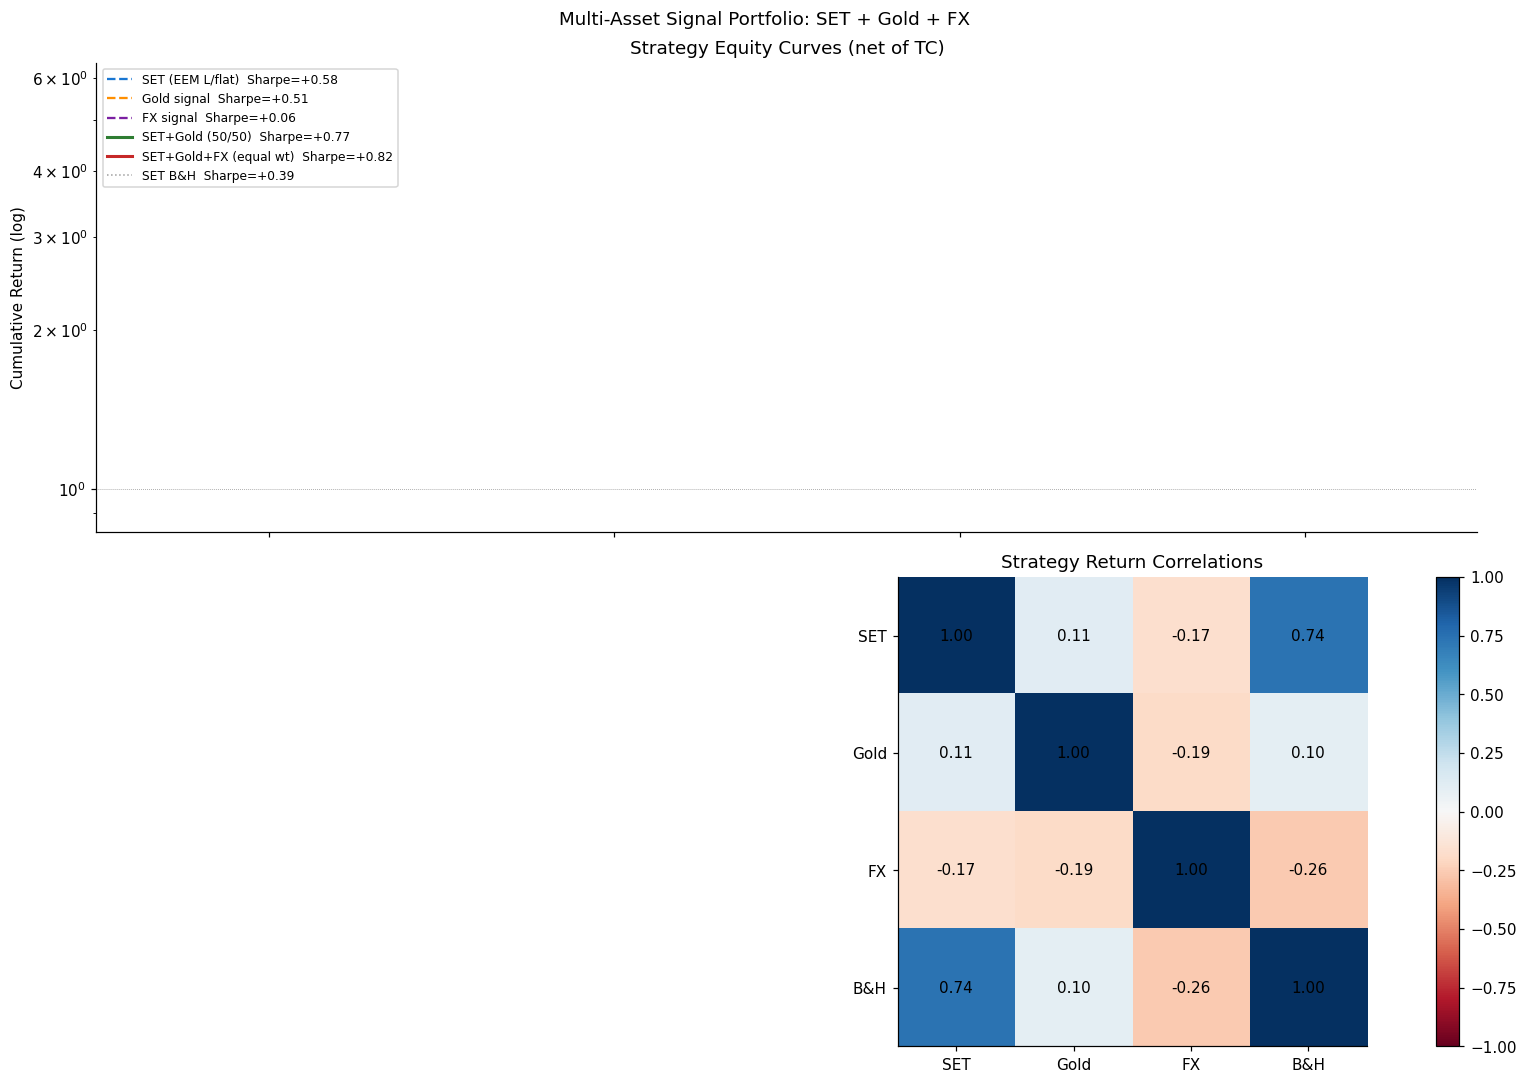

Saved: figs/multi_asset_equity.png


In [8]:
# ── Equity curves ──
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Multi-Asset Signal Portfolio: SET + Gold + FX', fontsize=12)

ax = axes[0]
for rets, lbl, col, lw, ls in [
    (r_set,       'SET (EEM L/flat)',       '#1976D2', 1.5, '--'),
    (r_gold,      'Gold signal',            '#FF8F00', 1.5, '--'),
    (r_fx,        'FX signal',              '#7B1FA2', 1.5, '--'),
    (r_set_gold,  'SET+Gold (50/50)',        '#2E7D32', 2.0, '-'),
    (r_multi,     'SET+Gold+FX (equal wt)', '#C62828', 2.0, '-'),
    (r_bnh,       'SET B&H',                '#9E9E9E', 1.0, ':'),
]:
    m   = risk_metrics(rets)
    cum = (1 + rets.dropna()).cumprod()
    ax.plot(cum, lw=lw, ls=ls, color=col,
            label=f'{lbl}  Sharpe={m.get("sharpe",0):+.2f}')
ax.axhline(1.0, color='gray', lw=0.5, ls=':')
ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log)')
ax.legend(fontsize=8, loc='upper left')
ax.set_title('Strategy Equity Curves (net of TC)')

# Correlation matrix of strategy returns
ret_mat = pd.DataFrame({'SET':r_set,'Gold':r_gold,'FX':r_fx,'B&H':r_bnh}).dropna()
corr = ret_mat.corr()
ax2 = axes[1]
im2 = ax2.imshow(corr.values, cmap='RdBu', vmin=-1, vmax=1)
ax2.set_xticks(range(4)); ax2.set_xticklabels(corr.columns)
ax2.set_yticks(range(4)); ax2.set_yticklabels(corr.index)
for i in range(4):
    for j in range(4):
        ax2.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im2, ax=ax2, fraction=0.03)
ax2.set_title('Strategy Return Correlations')
plt.tight_layout()
plt.savefig(FIGS / 'multi_asset_equity.png', bbox_inches='tight')
plt.show()
print('Saved: figs/multi_asset_equity.png')

---
## Section 5 — Verdict

In [9]:
from scipy.stats import ttest_1samp

print('='*65)
print('CROSS-ASSET SIGNAL VERDICT')
print('='*65)
print(f'{"Asset":<12} {"Best signal":<28} {"IC":>6} {"p":>7} {"Sharpe":>8} {"Viable?"}')
print('-'*75)

for asset, tgt_col, strategy_ret in [
    ('SET',    TARGET_SET,  r_set),
    ('Gold',   TARGET_GOLD, r_gold),
    ('USD/THB',TARGET_FX,   r_fx),
]:
    best_sig = ic_grid[asset if asset != 'USD/THB' else 'USDTHB'].dropna().abs().idxmax()
    tgt_key  = asset if asset != 'USD/THB' else 'USDTHB'
    ic_v  = ic_grid.loc[best_sig, tgt_key]
    p_v   = p_grid.loc[best_sig, tgt_key]
    m     = risk_metrics(strategy_ret)
    viable = 'YES ✓' if m.get('sharpe',0) > 0.3 and p_v < 0.05 else 'WEAK' if m.get('sharpe',0) > 0 else 'NO'
    print(f'{asset:<12} {best_sig:<28} {ic_v:>+6.3f} {p_v:>7.4f} {m.get("sharpe",0):>8.3f} {viable}')

print(f'\nMulti-asset portfolio (SET+Gold+FX):')
m_multi = risk_metrics(r_multi)
_, p_multi = ttest_1samp(r_multi.dropna(), 0)
print(f'  Sharpe={m_multi["sharpe"]:+.3f}  AnnRet={m_multi["ann_ret"]:+.2%}  MaxDD={m_multi["max_dd"]:+.1%}  p={p_multi:.4f}')
if m_multi['sharpe'] > risk_metrics(r_set)['sharpe']:
    print('  => Multi-asset IMPROVES on single-asset SET strategy')
else:
    print('  => Multi-asset does NOT improve on SET-only')

CROSS-ASSET SIGNAL VERDICT
Asset        Best signal                      IC       p   Sharpe Viable?
---------------------------------------------------------------------------
SET          sp500_ret_w                  +0.126  0.0000    0.584 YES ✓
Gold         yield_curve_slope            -0.052  0.0594    0.508 WEAK
USD/THB      dxy_ret_w                    +0.145  0.0000    0.058 WEAK

Multi-asset portfolio (SET+Gold+FX):
  Sharpe=+0.823  AnnRet=+4.87%  MaxDD=-20.5%  p=0.0001
  => Multi-asset IMPROVES on single-asset SET strategy
